# People Counting System on Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Uni/Ki-6-Nam-3/DS200

/content/drive/MyDrive/Uni/Ki-6-Nam-3/DS200


In [8]:
!git init
!git remote add -f origin https://github.com/nhatvu205/big-data-analytics-assignments-submission.git
!git sparse-checkout init --cone
!git sparse-checkout set lab5

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Uni/Ki-6-Nam-3/DS200/.git/
Updating origin
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 117 (delta 18), reused 115 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 1.32 MiB | 7.75 MiB/s, done.
Resolving deltas: 100% (18/18), done.
From https://github.com/nhatvu205/big-data-analytics-assignments-submission
 * [new branch]      m

In [34]:
!git pull origin main

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 9 (delta 6), reused 9 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 1.20 KiB | 8.00 KiB/s, done.
From https://github.com/nhatvu205/big-data-analytics-assignments-submission
 * branch            main       -> FETCH_HEAD
   4a3a138..30a0e99  main       -> origin/main
Updating 4a3a138..30a0e99
Fast-forward
 lab5/camera_server/producer.py     |  7 +++++--
 lab5/processing_server/consumer.py |  9 ++++++++-
 lab5/storage_server/db.py          | 29 +++++++++++++++++++----------
 3 files changed, 32 insertions(+), 13 deletions(-)


In [3]:
%cd lab5

/content/drive/MyDrive/Uni/Ki-6-Nam-3/DS200/lab5


In [4]:
!pip install -r requirements.txt

## Set up Apache Kafka

In [6]:
%%bash
set -euo pipefail
KAFKA_VERSION=3.7.2
KAFKA_SCALA=2.13
KAFKA_TGZ="kafka_${KAFKA_SCALA}-${KAFKA_VERSION}.tgz"
KAFKA_DIR="kafka_${KAFKA_SCALA}-${KAFKA_VERSION}"
KAFKA_URL="https://archive.apache.org/dist/kafka/${KAFKA_VERSION}/${KAFKA_TGZ}"
echo "$KAFKA_URL"
rm -f "$KAFKA_TGZ"
wget "$KAFKA_URL" -O "$KAFKA_TGZ"
ls -lh "$KAFKA_TGZ"

https://archive.apache.org/dist/kafka/3.7.2/kafka_2.13-3.7.2.tgz
-rw------- 1 root root 116M Dec 13  2024 kafka_2.13-3.7.2.tgz


--2026-06-11 09:17:43--  https://archive.apache.org/dist/kafka/3.7.2/kafka_2.13-3.7.2.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 120713953 (115M) [application/x-gzip]
Saving to: ‘kafka_2.13-3.7.2.tgz’

     0K .......... .......... .......... .......... ..........  0%  140K 14m1s
    50K .......... .......... .......... .......... ..........  0%  136K 14m12s
   100K .......... .......... .......... .......... ..........  0% 46.0M 9m28s
   150K .......... .......... .......... .......... ..........  0%  653K 7m51s
   200K .......... .......... .......... .......... ..........  0% 87.2K 10m46s
   250K .......... .......... .......... .......... ..........  0% 1.62M 9m10s
   300K .......... .......... .......... .......... ..........  0%  317K 8m44s
   350K .......... .......... .......... .........

In [7]:
%%bash
set -e
KAFKA_VERSION=3.7.2
KAFKA_SCALA=2.13
KAFKA_TGZ="kafka_${KAFKA_SCALA}-${KAFKA_VERSION}.tgz"
KAFKA_DIR="kafka_${KAFKA_SCALA}-${KAFKA_VERSION}"
KAFKA_HOME="/content/kafka"

rm -rf "$KAFKA_DIR" "$KAFKA_HOME"
tar -xzf "$KAFKA_TGZ"
mv "$KAFKA_DIR" "$KAFKA_HOME"
ls -lh "$KAFKA_HOME"

total 72K
drwx------ 3 root root 4.0K Dec  4  2024 bin
drwx------ 3 root root 4.0K Jun 11 09:30 config
drwx------ 2 root root  12K Jun 11 09:30 libs
-rw------- 1 root root  15K Dec  4  2024 LICENSE
drwx------ 2 root root 4.0K Dec  4  2024 licenses
-rw------- 1 root root  28K Dec  4  2024 NOTICE
drwx------ 2 root root 4.0K Dec  4  2024 site-docs


In [8]:
%%bash
set -e
KAFKA_HOME="/content/kafka"
rm -rf /content/kraft-combined-logs
export KAFKA_CLUSTER_ID=$($KAFKA_HOME/bin/kafka-storage.sh random-uuid)
$KAFKA_HOME/bin/kafka-storage.sh format -t "$KAFKA_CLUSTER_ID" -c "$KAFKA_HOME/config/kraft/server.properties"

Formatting /tmp/kraft-combined-logs with metadata.version 3.7-IV4.


In [9]:
%%bash
set -e
KAFKA_HOME="/content/kafka"
$KAFKA_HOME/bin/kafka-server-start.sh "$KAFKA_HOME/config/kraft/server.properties" > /tmp/kafka.log 2>&1 &
sleep 20
tail -50 /tmp/kafka.log

	transaction.max.timeout.ms = 900000
	transaction.partition.verification.enable = true
	transaction.remove.expired.transaction.cleanup.interval.ms = 3600000
	transaction.state.log.load.buffer.size = 5242880
	transaction.state.log.min.isr = 1
	transaction.state.log.num.partitions = 50
	transaction.state.log.replication.factor = 1
	transaction.state.log.segment.bytes = 104857600
	transactional.id.expiration.ms = 604800000
	unclean.leader.election.enable = false
	unstable.api.versions.enable = false
	unstable.metadata.versions.enable = false
	zookeeper.clientCnxnSocket = null
	zookeeper.connect = null
	zookeeper.connection.timeout.ms = null
	zookeeper.max.in.flight.requests = 10
	zookeeper.metadata.migration.enable = false
	zookeeper.metadata.migration.min.batch.size = 200
	zookeeper.session.timeout.ms = 18000
	zookeeper.set.acl = false
	zookeeper.ssl.cipher.suites = null
	zookeeper.ssl.client.enable = false
	zookeeper.ssl.crl.enable = false
	zookeeper.ssl.enabled.protocols = null
	zookee

In [10]:
%%bash
set -e
KAFKA_HOME="/content/kafka"
$KAFKA_HOME/bin/kafka-topics.sh --create --topic raw-frames --bootstrap-server localhost:9092 --partitions 2 --replication-factor 1 || true
$KAFKA_HOME/bin/kafka-topics.sh --create --topic detection-results --bootstrap-server localhost:9092 --partitions 2 --replication-factor 1 || true
$KAFKA_HOME/bin/kafka-topics.sh --list --bootstrap-server localhost:9092

Created topic raw-frames.
Created topic detection-results.
detection-results
raw-frames


## Input sample video

In [11]:
from pathlib import Path

video_path = Path('videos/input.mp4')
video_path.parent.mkdir(parents=True, exist_ok=True)
if not video_path.exists():
    raise FileNotFoundError('Please upload your video to videos/input.mp4 before running this cell.')
print(f'Using input video: {video_path}')


Using input video: videos/input.mp4


In [35]:
import threading
import time
import uvicorn
from camera_server.producer import run_camera_server
from processing_server.consumer import run_processing_server
from storage_server.consumer import run_storage_consumer

def start_api():
    uvicorn.run('storage_server.api:app', host='0.0.0.0', port=8000, reload=False)

threads = [
    threading.Thread(target=run_storage_consumer, daemon=True),
    threading.Thread(target=run_processing_server, daemon=True),
    threading.Thread(target=start_api, daemon=True),
]
for t in threads:
    t.start()
time.sleep(5)
run_camera_server(video_path, max_frames=30)


INFO:     Started server process [10842]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [36]:
import json
import time
from storage_server.db import StorageDB

time.sleep(10)
db = StorageDB()
stats = db.get_stats()
latest = db.get_latest(10)
print(json.dumps(stats, indent=2))
print(json.dumps(latest[:2], indent=2))


{
  "avg_count": 10.733333333333333,
  "max_count": 16,
  "total_frames": 90
}
[
  {
    "frame_id": 29,
    "timestamp": 1781171156.856265,
    "processed_at": 1781171156.896028,
    "source_id": "camera-1",
    "person_count": 10,
    "bounding_boxes": [
      {
        "x1": 320,
        "y1": 49,
        "x2": 361,
        "y2": 141,
        "confidence": 0.751
      },
      {
        "x1": 426,
        "y1": 215,
        "x2": 466,
        "y2": 275,
        "confidence": 0.728
      },
      {
        "x1": 579,
        "y1": 196,
        "x2": 640,
        "y2": 268,
        "confidence": 0.711
      },
      {
        "x1": 364,
        "y1": 0,
        "x2": 403,
        "y2": 85,
        "confidence": 0.614
      },
      {
        "x1": 518,
        "y1": 275,
        "x2": 592,
        "y2": 340,
        "confidence": 0.549
      },
      {
        "x1": 208,
        "y1": 194,
        "x2": 259,
        "y2": 270,
        "confidence": 0.469
      },
      {
        "x1":

In [37]:
import json
from pathlib import Path
from kafka import KafkaConsumer
from utils.visualization import save_annotated_frame

Path('results').mkdir(exist_ok=True)
with open('results/sample_output.json', 'w') as f:
    json.dump(latest, f, indent=2)

sample = latest[0] if latest else None
if sample and sample.get('bounding_boxes'):
    target_frame_id = sample['frame_id']
    target_run_id = sample.get('run_id')

    consumer = KafkaConsumer(
        'raw-frames',
        bootstrap_servers='localhost:9092',
        value_deserializer=lambda m: json.loads(m.decode('utf-8')),
        auto_offset_reset='earliest',
        consumer_timeout_ms=5000,
        group_id='preview-group',
        enable_auto_commit=False,
        max_partition_fetch_bytes=10_000_000,
        fetch_max_bytes=10_000_000,
    )

    matched_frame = None
    for msg in consumer:
        frame = msg.value
        if (
            frame.get('frame_id') == target_frame_id
            and frame.get('run_id') == target_run_id
        ):
            matched_frame = frame
            break
    consumer.close()

    if matched_frame is None:
        raise ValueError(f'Could not find raw frame with frame_id={target_frame_id} for annotation.')

    save_annotated_frame(
        matched_frame['frame_data'],
        sample['bounding_boxes'],
        'results/annotated_frame.jpg',
    )
    print(f"Annotated frame saved for frame_id={target_frame_id}")
else:
    print('No detection results available to annotate.')

print('Saved results/sample_output.json and results/annotated_frame.jpg')


ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-2.3.2, node_id=1 host=localhost:9092 <connected> [IPv6 ('::1', 9092, 0, 0)]>: Closing connection. InvalidReceiveError: Invalid frame length: 3162732
ERROR:kafka.consumer.fetcher:Fetch to node 1 failed: InvalidReceiveError: Invalid frame length: 3162732


Annotated frame saved for frame_id=29
Saved results/sample_output.json and results/annotated_frame.jpg


## Preview 1 frame kèm bounding box trong video

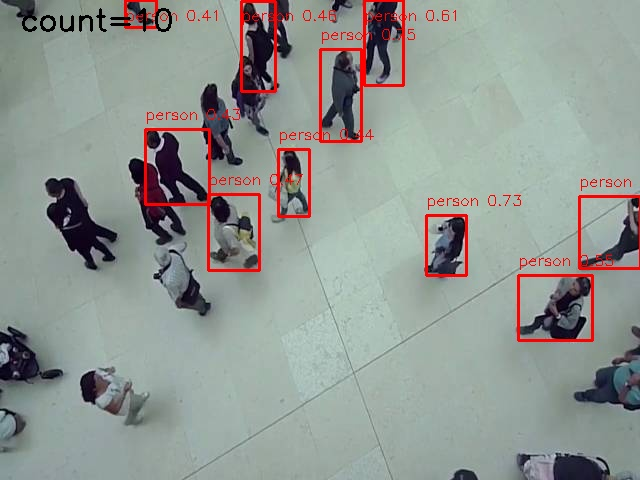

In [41]:
from IPython.display import Image, display

display(Image(filename="results/annotated_frame.jpg"))